In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df = df[['v1', 'v2']]
display(df.head())

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder();


In [10]:
df['v1']=encoder.fit_transform(df['v1'])

In [11]:
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
#missing value

df.isnull().sum()

v1    0
v2    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape


(5169, 2)

# EDA





In [17]:
df['v1'].value_counts()

v1
0    4516
1     653
Name: count, dtype: int64

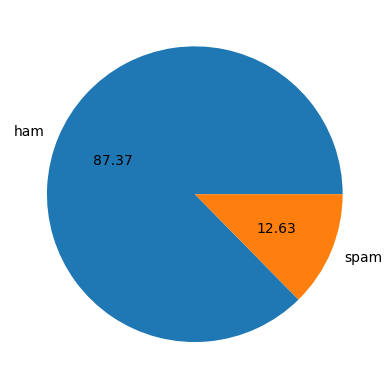

In [18]:
import matplotlib.pyplot as plt
plt.pie(df['v1'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

In [48]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])

0

In [20]:
import nltk

In [21]:
df['num_char'] =df['v2'].apply(len)

In [22]:
df.head()

,v1,v2,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
import nltk
nltk.download('punkt_tab')
df['num_words'] = df['v2'].apply(lambda x:nltk.word_tokenize(x))

[nltk_data] Downloading package punkt_tab to C:\Users\Jeel
[nltk_data]     Patel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


<Axes: xlabel='num_char', ylabel='Count'>

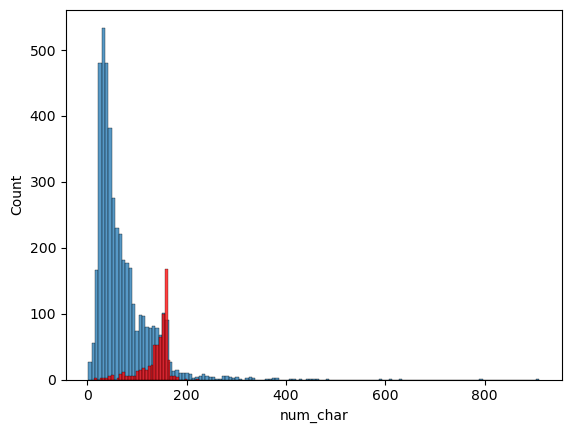

In [24]:
import seaborn as sns

sns.histplot(df[df['v1']==0]['num_char'])
sns.histplot(df[df['v1']==1]['num_char'],color='red')

Data PreProcessing

In [25]:
#lowercase letter
df['v2'] = df['v2'].str.lower()

In [26]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords') # Make sure stopwords are downloaded
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to C:\Users\Jeel
[nltk_data]     Patel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [28]:
df['trasnformed_text'] = df['v2'].apply(transform_text)

# model Building

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
tv = TfidfVectorizer(max_features=3000)
x = tv.fit_transform(df['trasnformed_text']).toarray()

In [33]:
x.shape

(5169, 3000)

In [34]:
df.head()

,v1,v2,num_char,num_words,trasnformed_text
0,0,"go until jurong point, crazy.. available only ...",111,"[Go, until, jurong, point, ,, crazy, .., Avail...",go jurong point crazi avail bugi n great world...
1,0,ok lar... joking wif u oni...,29,"[Ok, lar, ..., Joking, wif, u, oni, ...]",ok lar joke wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...,155,"[Free, entry, in, 2, a, wkly, comp, to, win, F...",free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say so early hor... u c already then say...,49,"[U, dun, say, so, early, hor, ..., U, c, alrea...",u dun say earli hor u c alreadi say
4,0,"nah i don't think he goes to usf, he lives aro...",61,"[Nah, I, do, n't, think, he, goes, to, usf, ,,...",nah think goe usf live around though


In [35]:
y = df['v1'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [37]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score

In [38]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [39]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)


In [40]:
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

0.8694390715667312
[[788 108]
 [ 27 111]]


In [41]:
print(precision_score(y_test,y_pred1))
print(recall_score(y_test,y_pred1))

0.5068493150684932
0.8043478260869565


In [42]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)


In [43]:
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]


In [44]:
print(precision_score(y_test,y_pred2))
print(recall_score(y_test,y_pred2))

1.0
0.782608695652174


In [45]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)

In [46]:
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))


0.9835589941972921
[[895   1]
 [ 16 122]]


In [47]:
print(precision_score(y_test,y_pred3))
print(recall_score(y_test,y_pred3))

0.991869918699187
0.8840579710144928


#base on output i prefered  MultinomialNB because precision value would be 1


In [53]:
import pickle



pickle.dump(tv, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))

In [54]:

# Load the vectorizer
with open('vectorizer.pkl', 'rb') as f:
    tv = pickle.load(f)

# Load the model
with open('model.pkl', 'rb') as f:
    mnb = pickle.load(f)

In [ ]:
with open('vectorizer.pkl', 'wb') as f:
         pickle.dump(tv, f)


with open('model.pkl', 'wb') as f:
    pickle.dump(mnb, f)